# WGAN-GP Data Augmentation for Rare Emotion Classes

This notebook implements a **Wasserstein GAN with Gradient Penalty (WGAN-GP)** for generating synthetic samples of rare emotion classes to balance the dataset.

**Key Features:**
- Wasserstein loss for stable training
- Gradient penalty for Lipschitz constraint
- Conditional generation (class-specific)
- Mixed precision training for speed

**Rare Classes Target:** DISGUST, SURPRISE(< 15% of max class)

## Section 1: Monta Google Drive
Necessario per leggere il dataset e salvare modelli/output su Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Section 2: Import e check GPU
Importa TensorFlow/NumPy, controlla versione e disponibilità GPU.

In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import h5py, os

print('TF', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TF 2.19.0
GPU available: True


## Section 3: Caricamento dataset HDF5
Carica train/val da `dataset.h5` e unisce i due split per l'analisi.

In [19]:
DATASET_PATH = '/content/drive/MyDrive/TESI_POLITO/dataset/dataset/dataset.h5'
with h5py.File(DATASET_PATH, 'r') as f:
    X_train = np.array(f['X_train'])
    y_train = np.array(f['y_train'])
    X_val = np.array(f['X_val'])
    y_val = np.array(f['y_val'])
    class_names = [c.decode('utf-8') for c in f['class_names']]
X = np.concatenate([X_train, X_val])
y = np.concatenate([y_train, y_val])
print('Shapes', X.shape, y.shape)

Shapes (26605, 128, 128, 3) (26605,)


## Section 4: Individuazione classi rare
Trova classi con frequenza <15% della classe più numerosa e visualizza la distribuzione.

Rare classes: {np.int64(1): 'DISGUST', np.int64(6): 'SURPRISE'}
ANGRY     : 3286
DISGUST   : 642
FEAR      : 2843
HAPPY     : 13742
NEUTRAL   : 2457
SAD       : 2848
SURPRISE  : 787


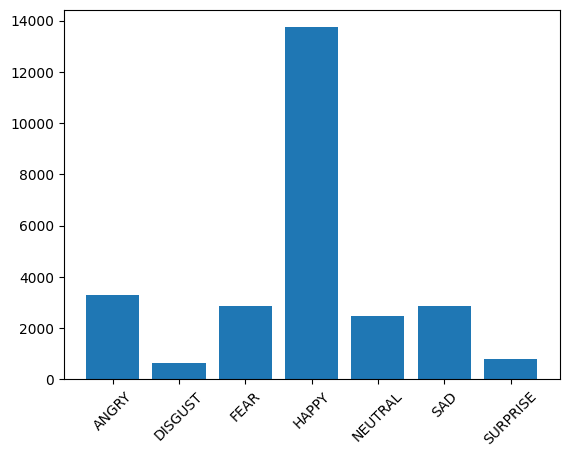

In [4]:
counts = np.bincount(y)
max_count = counts.max()
rare_idx = np.where(counts < 0.15 * max_count)[0]
rare_names = [class_names[i] for i in rare_idx]
print('Rare classes:', dict(zip(rare_idx, rare_names)))
for i, n in enumerate(class_names):
    print(f'{n:10s}: {counts[i]}')
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.show()

## Section 5: Prepara subset classi rare
Filtra solo le classi rare, normalizza in [-1,1], rimappa etichette a indice locale e applica one-hot.

In [5]:
mask = np.isin(y, rare_idx)
X_rare = X[mask].astype('float32') / 127.5 - 1.0
y_rare = y[mask]
label_map = {old:new for new, old in enumerate(rare_idx)}
y_remap = np.array([label_map[v] for v in y_rare])
num_classes = len(rare_idx)
y_onehot = tf.keras.utils.to_categorical(y_remap, num_classes)
print('Rare subset', X_rare.shape, y_onehot.shape)

Rare subset (1429, 128, 128, 3) (1429, 2)


## Section 6: Hyperparameter setup
Definisci dimensione immagine, latente, batch, LR e parametri WGAN-GP (λ_GP, critic_steps).

In [6]:
IMG_SHAPE = (128,128,3)
NOISE_DIM = 100
BATCH_SIZE = 64
LR_C = 5e-5
LR_G = 2e-4
BETA1 = 0.5
LAMBDA_GP = 20
CRITIC_STEPS = 4

## Section 7: Definizione modelli WGAN-GP
Generator: noise+label → immagine. Critic condizionato (senza BatchNorm).

In [7]:
def build_generator():
    noise = tf.keras.Input(shape=(NOISE_DIM,))
    label = tf.keras.Input(shape=(num_classes,))
    x = tf.keras.layers.Concatenate()([noise, label])
    x = tf.keras.layers.Dense(16*16*256, activation='relu')(x)
    x = tf.keras.layers.Reshape((16,16,256))(x)
    for f in [256,128,64]:
        x = tf.keras.layers.Conv2DTranspose(f, 4, strides=2, padding='same', activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
    out = tf.keras.layers.Conv2D(3, 3, padding='same', activation='tanh')(x)
    return tf.keras.Model([noise, label], out)

def build_critic():
    img = tf.keras.Input(shape=IMG_SHAPE)
    label = tf.keras.Input(shape=(num_classes,))
    l = tf.keras.layers.Reshape((1,1,num_classes))(label)
    l = tf.keras.layers.UpSampling2D((IMG_SHAPE[0], IMG_SHAPE[1]))(l)
    x = tf.keras.layers.Concatenate()([img, l])
    for f in [64,128,256]:
        x = tf.keras.layers.Conv2D(f, 4, strides=2, padding='same')(x)
        x = tf.keras.layers.LeakyReLU(0.2)(x)
    x = tf.keras.layers.Flatten()(x)
    out = tf.keras.layers.Dense(1)(x)
    return tf.keras.Model([img, label], out)

G = build_generator()
C = build_critic()
G.summary(); C.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 102)       │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 65536)     │  6,750,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 16, 16,    │          0 │ dense[0][0]       │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │  1,048,832 │ reshape[0][0]     │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 64, 64,    │    524,416 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 128, 128,  │    131,136 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,731 │ batch_normalizat… │
│                     │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,458,115 (32.27 MB)

 Trainable params: 8,457,219 (32.26 MB)

 Non-trainable params: 896 (3.50 KB)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 2)   │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ reshape_1[0][0]   │
│ (UpSampling2D)      │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ input_layer_2[0]… │
│ (Concatenate)       │ 5)                │            │ up_sampling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      5,184 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │    131,200 │ leaky_re_lu[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 32, 32,    │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │    524,544 │ leaky_re_lu_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 65536)     │          0 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │     65,537 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 726,465 (2.77 MB)

 Trainable params: 726,465 (2.77 MB)

 Non-trainable params: 0 (0.00 B)

## Section 8: Funzioni WGAN-GP (loss + gradient penalty)
Implementa il gradient penalty e le loss WGAN (no sigmoid, critic in logit).

In [8]:
crit_opt = tf.keras.optimizers.Adam(LR_C, beta_1=BETA1, beta_2=0.9, clipnorm=5.0)
gen_opt = tf.keras.optimizers.Adam(LR_G, beta_1=BETA1, beta_2=0.9)

@tf.function
def gradient_penalty(real_img, fake_img, labels):
    alpha = tf.random.uniform([tf.shape(real_img)[0], 1,1,1], 0.0, 1.0)
    inter = alpha * real_img + (1 - alpha) * fake_img
    with tf.GradientTape() as gp_tape:
        gp_tape.watch(inter)
        pred = C([inter, labels], training=True)
    grads = gp_tape.gradient(pred, inter)
    norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1,2,3]) + 1e-10)
    return tf.reduce_mean((norm - 1.0) ** 2)

## Section 9: Training loop WGAN-GP
Critic step ripetuto (n=5), poi update generator; logga le loss.

In [ ]:
# Checkpoint directory e path best
CKPT_DIR = '/content/drive/MyDrive/TESI_POLITO/WGAN_GP_augmentation'
os.makedirs(CKPT_DIR, exist_ok=True)
BEST_GEN_PATH = os.path.join(CKPT_DIR, 'best_generator_wgan_gp.h5')
BEST_CRIT_PATH = os.path.join(CKPT_DIR, 'best_critic_wgan_gp.h5')

@tf.function
def train_step(real_img, labels):
    bs = tf.shape(real_img)[0]
    # Update Critic n volte
    for _ in tf.range(CRITIC_STEPS):
        noise = tf.random.normal((bs, NOISE_DIM))
        with tf.GradientTape() as tape:
            fake_img = G([noise, labels], training=True)
            real_out = C([real_img, labels], training=True)
            fake_out = C([fake_img, labels], training=True)
            gp = gradient_penalty(real_img, fake_img, labels)
            c_loss = tf.reduce_mean(fake_out) - tf.reduce_mean(real_out) + LAMBDA_GP * gp
        grads = tape.gradient(c_loss, C.trainable_variables)
        crit_opt.apply_gradients(zip(grads, C.trainable_variables))
    # Update Generator
    noise = tf.random.normal((bs, NOISE_DIM))
    with tf.GradientTape() as tape:
        fake_img = G([noise, labels], training=True)
        fake_out = C([fake_img, labels], training=True)
        g_loss = -tf.reduce_mean(fake_out)
    grads = tape.gradient(g_loss, G.trainable_variables)
    gen_opt.apply_gradients(zip(grads, G.trainable_variables))
    return c_loss, g_loss

def train(epochs=150):
    ds = tf.data.Dataset.from_tensor_slices((X_rare, y_onehot)).shuffle(len(X_rare)).batch(BATCH_SIZE)
    c_hist, g_hist = [], []
    best_g = np.inf
    for epoch in range(epochs):
        c_loss_epoch = g_loss_epoch = 0.0; steps = 0
        for real_img, labels in ds:
            c_loss, g_loss = train_step(real_img, labels)
            c_loss_epoch += c_loss; g_loss_epoch += g_loss; steps += 1
        c_hist.append(float(c_loss_epoch/steps)); g_hist.append(float(g_loss_epoch/steps))
        if g_hist[-1] < best_g:
            best_g = g_hist[-1]
            G.save(BEST_GEN_PATH)
            C.save(BEST_CRIT_PATH)
            print(f'Saved best at epoch {epoch+1} (Gen: {best_g:.3f})')
        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs} - Critic: {c_hist[-1]:.3f} - Gen: {g_hist[-1]:.3f}')
    return c_hist, g_hist

c_losses, g_losses = train(epochs=100)
plt.plot(c_losses, label='Critic'); plt.plot(g_losses, label='Gen'); plt.legend(); plt.show()

## Section 10: Generazione sintetici
Per ogni classe rara genera campioni (≈25% del max), denormalizza a uint8.

In [7]:
# Carica il best generator prima di generare
BEST_GEN_PATH = '/content/drive/MyDrive/TESI_POLITO/WGAN_GP_augmentation/best_generator_wgan_gp.h5'
if os.path.exists(BEST_GEN_PATH):
    G_best = tf.keras.models.load_model(BEST_GEN_PATH, compile=False)
else:
    G_best = G  # fallback se non trovato

target_per_class = int(max_count * 0.25)
synth_images = []
synth_labels = []
for cid in range(num_classes):
    noise = tf.random.normal((target_per_class, NOISE_DIM))
    labels = np.zeros((target_per_class, num_classes), dtype=np.float32)
    labels[:, cid] = 1
    imgs = G_best.predict([noise, labels], verbose=0)
    synth_images.append(imgs)
    synth_labels += [cid]*target_per_class
synth_images = np.concatenate(synth_images)
synth_images_uint8 = ((synth_images + 1)/2 * 255).astype(np.uint8)
synth_labels = np.array(synth_labels)
print('Synthetic set', synth_images_uint8.shape, synth_labels.shape)

Synthetic set (6870, 128, 128, 3) (6870,)


## Section 11: Anteprima sintetici
Visualizza una griglia di esempi generati per controllo qualitativo.

In [ ]:
fig, ax = plt.subplots(2,5, figsize=(10,4))
for i in range(10):
    r, c = divmod(i,5)
    ax[r,c].imshow(synth_images_uint8[i])
    ax[r,c].axis('off')
plt.show()

#Section 12: Filtro immagini generate

In [ ]:
# IMPORTANTE: Libera memoria prima di allenare il classifier
import gc

# Elimina variabili pesanti non più necessarie
del X_train, X_val, X, y, y_train, y_val
gc.collect()

print('Memoria liberata. Avvia training classifier...\n')

# Ora continua con il training
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ricarica SOLO i dati train/val (senza tenerli in memoria sempre)
# Opzione 1: Carica da file se salvi in precedenza
DATASET_PATH = '/content/drive/MyDrive/TESI_POLITO/dataset/dataset/dataset.h5'
with h5py.File(DATASET_PATH, 'r') as f:
     X_train = np.array(f['X_train'])
     y_train = np.array(f['y_train'])
     X_val = np.array(f['X_val'])
     y_val = np.array(f['y_val'])

# Opzione 2: Usa ImageDataGenerator da cartelle (se hai i file divisi)
# train_datagen = ImageDataGenerator(rescale=1./255)
# train_gen = train_datagen.flow_from_directory(
#     '/path/to/train/',
#     target_size=(128, 128),
#     batch_size=64,
#     class_mode='sparse'
# )
# val_gen = train_datagen.flow_from_directory(
#     '/path/to/val/',
#     target_size=(128, 128),
#     batch_size=64,
#     class_mode='sparse'
# )

# Se hai X_train, X_val ancora in memoria dopo il del, usali così:
print(f'Train: {X_train.shape}, Val: {X_val.shape}')
print(f'Classi: 7')

# Costruisci classifier
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(7, activation='softmax')(x)

classifier = models.Model(inputs, outputs)

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 32  # Riduci a 32 se ancora OOM

train_gen = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_datagen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print('\n--- Phase 1: Training head (base frozen) ---')
history1 = classifier.fit(
    train_gen,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=len(X_val) // BATCH_SIZE,
    epochs=10,
    verbose=1
)

# Phase 2: Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_gen = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

print('\n--- Phase 2: Fine-tuning ---')
history2 = classifier.fit(
    train_gen,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=len(X_val) // BATCH_SIZE,
    epochs=15,
    verbose=1
)

# Salva
CLASSIFIER_PATH = '/content/drive/MyDrive/TESI_POLITO/WGAN_GP_augmentation/filter_classifier.h5'
classifier.save(CLASSIFIER_PATH)
print(f'Classifier salvato: {CLASSIFIER_PATH}')

# Cleanup
del train_gen, val_gen, X_train, X_val, y_train, y_val
gc.collect()

Memoria liberata. Avvia training classifier...

Train: (21332, 128, 128, 3), Val: (5273, 128, 128, 3)
Classi: 7

--- Phase 1: Training head (base frozen) ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
666/666 ━━━━━━━━━━━━━━━━━━━━ 150s 177ms/step - accuracy: 0.5080 - loss: 1.5380 - val_accuracy: 0.5189 - val_loss: 1.4851
Epoch 2/10
  1/666 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.3750 - loss: 1.9618

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


666/666 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3750 - loss: 1.9618 - val_accuracy: 0.5189 - val_loss: 1.4840
Epoch 3/10
666/666 ━━━━━━━━━━━━━━━━━━━━ 91s 136ms/step - accuracy: 0.5131 - loss: 1.5182 - val_accuracy: 0.5189 - val_loss: 1.4836
Epoch 4/10
666/666 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5625 - loss: 1.4658 - val_accuracy: 0.5189 - val_loss: 1.4854
Epoch 5/10
666/666 ━━━━━━━━━━━━━━━━━━━━ 91s 136ms/step - accuracy: 0.5175 - loss: 1.5038 - val_accuracy: 0.5189 - val_loss: 1.4875
Epoch 6/10
666/666 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4688 - loss: 1.5793 - val_accuracy: 0.5189 - val_loss: 1.4891
Epoch 7/10
666/666 ━━━━━━━━━━━━━━━━━━━━ 95s 142ms/step - accuracy: 0.5180 - loss: 1.5002 - val_accuracy: 0.5189 - val_loss: 1.4817
Epoch 8/10
666/666 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4062 - loss: 1.6198 - val_accuracy: 0.5189 - val_loss: 1.4822
Epoch 9/10
666/666 ━━━━━━━━━━━━━━━━━━━━ 104s 156ms/step - accuracy: 0.5163 - loss: 1.5023 - val_accuracy: 

In [ ]:
# Carica il classifier già addestrato (sostituisci con il tuo modello)
CLASSIFIER_PATH = '/content/drive/MyDrive/TESI_POLITO/models/best_classifier.h5'  # adatta il path
classifier = tf.keras.models.load_model(CLASSIFIER_PATH, compile=False)

# Carica le immagini sintetiche generate
synth_images_uint8 = np.load('/content/drive/MyDrive/TESI_POLITO/WGAN_GP_augmentation/synthetic_images.npy')
synth_labels = np.load('/content/drive/MyDrive/TESI_POLITO/WGAN_GP_augmentation/synthetic_labels.npy')
rare_idx = np.load('/content/drive/MyDrive/TESI_POLITO/WGAN_GP_augmentation/rare_class_indices.npy')

# Normalizza per il classifier (adatta al preprocessing del tuo modello)
synth_images_norm = synth_images_uint8.astype('float32') / 255.0

# Predici con il classifier
predictions = classifier.predict(synth_images_norm, batch_size=64, verbose=1)
pred_classes = np.argmax(predictions, axis=1)
pred_confidences = np.max(predictions, axis=1)

# Filtra: mantieni solo immagini con confidence >= threshold E classe corretta
CONFIDENCE_THRESHOLD = 0.70  # 70% di confidenza minima
mask_confident = pred_confidences >= CONFIDENCE_THRESHOLD
mask_correct_class = pred_classes == synth_labels  # verifica che predica la classe giusta
mask_keep = mask_confident & mask_correct_class

# Applica il filtro
filtered_images = synth_images_uint8[mask_keep]
filtered_labels = synth_labels[mask_keep]

print(f'Originali: {len(synth_images_uint8)} immagini')
print(f'Filtrate (confidence>={CONFIDENCE_THRESHOLD} e classe corretta): {len(filtered_images)} immagini')
print(f'Scartate: {len(synth_images_uint8) - len(filtered_images)} ({100*(1-len(filtered_images)/len(synth_images_uint8)):.1f}%)')

# Visualizza distribuzione per classe dopo il filtro
for cid in range(len(rare_idx)):
    count = np.sum(filtered_labels == cid)
    print(f'Classe {rare_idx[cid]} ({rare_names[cid]}): {count} immagini')

# Salva le immagini filtrate
np.save('/content/drive/MyDrive/TESI_POLITO/WGAN_GP_augmentation/synthetic_images_filtered.npy', filtered_images)
np.save('/content/drive/MyDrive/TESI_POLITO/WGAN_GP_augmentation/synthetic_labels_filtered.npy', filtered_labels)
print('Salvate immagini filtrate')

# Anteprima delle filtrate
fig, ax = plt.subplots(2, 5, figsize=(10,4))
for i in range(min(10, len(filtered_images))):
    r, c = divmod(i, 5)
    ax[r,c].imshow(filtered_images[i])
    ax[r,c].set_title(f'Conf: {pred_confidences[mask_keep][i]:.2f}')
    ax[r,c].axis('off')
plt.suptitle('Immagini filtrate (alta confidence)')
plt.show()

# Section 13
Salvataggio modelli e dataset sintetico
Salva generator/critic e i file `.npy` (immagini, etichette, indici classi rare) su Drive.

In [ ]:
OUT_DIR = '/content/drive/MyDrive/TESI_POLITO/WGAN_GP_augmentation'
os.makedirs(OUT_DIR, exist_ok=True)
G.save(os.path.join(OUT_DIR, 'generator_wgan_gp.h5'))
C.save(os.path.join(OUT_DIR, 'critic_wgan_gp.h5'))
np.save(os.path.join(OUT_DIR, 'synthetic_images.npy'), synth_images_uint8)
np.save(os.path.join(OUT_DIR, 'synthetic_labels.npy'), synth_labels)
np.save(os.path.join(OUT_DIR, 'rare_class_indices.npy'), rare_idx)
print('Saved to', OUT_DIR)

## Section 13: Ripresa training da pesi salvati

In [ ]:
# Section 13: Ripresa training da pesi salvati
import os
RESUME_DIR = '/content/drive/MyDrive/TESI_POLITO/WGAN_GP_augmentation'  # adatta se diverso

# Ricarica i modelli
G = tf.keras.models.load_model(os.path.join(RESUME_DIR, 'generator_wgan_gp.h5'), compile=False)
C = tf.keras.models.load_model(os.path.join(RESUME_DIR, 'critic_wgan_gp.h5'), compile=False)

IMG_SHAPE = (128,128,3)
NOISE_DIM = 100
BATCH_SIZE = 64
LR_C = 5e-5
LR_G = 1e-4
BETA1 = 0.5
LAMBDA_GP = 20
CRITIC_STEPS = 4


# Optimizer rebind
gen_opt = tf.keras.optimizers.Adam(LR_G, beta_1=BETA1, beta_2=0.9)
crit_opt = tf.keras.optimizers.Adam(LR_C, beta_1=BETA1, beta_2=0.9)

# dopo far partire codice del training
